# Проект: Исследование стартапов

- Автор: Сайпушева Ольга
- Дата: 19.04.2025

## Введение

### Цель и задачи  

**Цель:** исследование рынка стартапов с акцентом на изучении их финансирования.   

**Задачи:**
1. Загрузить данные и познакомиться с их содержимым.
2. Провести предобработку данных.
3. Провести исследовательский анализ данных:
    - изучить выбросы;
    - изучить цены стартапов по категориям;
    - исследовать среднее количество раундов для каждой категории стратпов.
4. Сформулировать выводы по проведённому анализу.

### Данные

Таблица `acquisition`
Содержит информацию о покупках одними компаниями других компаний:
- id — идентификатор покупки.
- acquiring_company_id — идентификатор покупающей компании.
- acquired_company_id — идентификатор покупаемой компании.
- term_code — варианты расчёта.
- price_amount — сумма сделки.
- acquired_at — дата сделки.

Таблица `company_and_rounds`
Содержит информацию о компаниях и раундах финансирования:
- company ID — идентификатор компании.
- name — название компании.
- category code — категория области деятельности компании.
- status — статус компании.
- founded at — дата инвестирования.
- closed at — дата закрытия компании.
- domain — официальный сайт компании.
- network username — ник компании в сети.
- country code — код страны компании.
- investment rounds — число инвестиционных раундов.
- funding rounds — число раундов финансирования.
- funding total — сумма финансирования.
- milestones — вехи финансирования.
- funding round id — идентификатор этапа финансирования.
- company id — идентификатор компании.
- funded at — дата финансирования.
- funding round type — тип финансирования.
- raised amount — сумма финансирования.
- pre money valuation — предварительная денежная оценка.
- participants — число участников.
- is first round — является ли раунд первым.
- is last round — является раунд последним.

Таблица `education`
Содержит информацию об образовании сотрудника:
- id — идентификатор записи об образовании.
- person_id — идентификатор работника.
- instituition — название учебного заведения.
- graduated_at — дата получения образования.

Таблица `people`
Содержит информацию о сотрудниках:
- id — идентификатор сотрудника.
- first_name — имя сотрудника.
- last_name — фамилия сотрудника.
- company_id — идентификатор компании.
- network_username — ник в социальных сетях.

Таблица `degrees`
Содержит информацию о типе образования сотрудника:
- id — идентификатор записи.
- object_id — идентификатор сотрудника.
- degree_type — тип образования.
- subject — специальность.

Данные, которые могут быть не использованы в проекте:

Таблица `fund`
Содержит информацию о фондах:
- id — идентификатор фонда.
- name — название фонда.
- category_code — категория области деятельности компании.
- founded_at — дата создания фонда.
- domain — сайт фонда.
- network_username — ник фонда в сети.
- country_code — код страны фонда.
- investment_rounds — число инвестиционных раундов.
- invested_companies — число профинансированных компаний.
- milestones — вехи финансирования.

Таблица `investment`
Содержит информацию о раундах инвестирования:
- id — идентификатор этапа инвестирования.
- funding_round_id — идентификатор раунда инвестирования.
- company_id — индентификатор компании.
- funding_round_type — тип финансирования.
- fund_id — идентификатор фонда.

### Структура проекта

1. Загрузка данных и знакомство с ними.
2. Предобработка данных, предварительное исследование.
3. Исследовательский анализ объединенных таблиц.
4. Итоговый вывод и рекомендации.

## Шаг 1. Знакомство с данными: загрузка и первичная предобработка

### 1.1. Вывод общей информации, исправление названия столбцов


In [1]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np 


In [2]:
# Выгружаем данные из датасетов в датафреймы
df_acquisition = pd.read_csv('https://code.s3.yandex.net/datasets/acquisition.csv')
df_company_and_rounds=pd.read_csv('https://code.s3.yandex.net/datasets/company_and_rounds.csv')
df_education=pd.read_csv('https://code.s3.yandex.net/datasets/education.csv')
df_people = pd.read_csv('https://code.s3.yandex.net/datasets/people.csv')
df_degrees=pd.read_csv('https://code.s3.yandex.net/datasets/degrees.csv')

In [3]:
# Выводим на экран названия всех столбцов датафрейма df_acquisition
df_acquisition.columns

Index(['id', 'acquiring_company_id', 'acquired_company_id', 'term_code',
       'price_amount', 'acquired_at'],
      dtype='object')

In [4]:
# Выводим на экран названия всех столбцов датафрейма df_company_and_rounds
df_company_and_rounds.columns

Index(['company  ID', 'name', 'category  code', 'status', 'founded  at',
       'closed  at', 'domain', 'network  username', 'country  code',
       'investment  rounds', 'funding  rounds', 'funding  total', 'milestones',
       'funding  round  id', 'company  id', 'funded  at',
       'funding  round  type', 'raised  amount', 'pre  money  valuation',
       'participants', 'is  first  round', 'is  last  round'],
      dtype='object')

In [5]:
# Выводим на экран названия всех столбцов датафрейма df_education
df_education.columns

Index(['id', 'person_id', 'instituition', 'graduated_at'], dtype='object')

In [6]:
# Выводим на экран названия всех столбцов датафрейма df_people
df_people.columns

Index(['id', 'first_name', 'last_name', 'company_id', 'network_username'], dtype='object')

In [7]:
# Выводим на экран названия всех столбцов датафрейма df_degrees
df_degrees.columns

Index(['id', 'object_id', 'degree_type', 'subject'], dtype='object')

Видим, что названия столбцов в датафрейме df_company_and_rounds не соответствуют стилю snake case, а также, 2 столбца имют одинаковое название `company ID` и `company id` (их пока оставим без изменения). Исправим названия столбцов:

In [8]:
columns_snake_case = ['company_ID', 'name', 'category_code', 'status', 'founded_at',
       'closed_at', 'domain', 'network_username', 'country_code',
       'investment_rounds', 'funding_rounds', 'funding_total', 'milestones',
       'funding_round_id', 'company_id', 'funded_at',
       'funding_round_type', 'raised_amount', 'pre_money_valuation',
       'participants', 'is_first_round', 'is_last_round']

In [9]:
# # Передаём список атрибуту columns датафрейма
df_company_and_rounds.columns = columns_snake_case

In [10]:
# Проверим изменения наваний столбцов df_company_and_rounds
df_company_and_rounds.columns

Index(['company_ID', 'name', 'category_code', 'status', 'founded_at',
       'closed_at', 'domain', 'network_username', 'country_code',
       'investment_rounds', 'funding_rounds', 'funding_total', 'milestones',
       'funding_round_id', 'company_id', 'funded_at', 'funding_round_type',
       'raised_amount', 'pre_money_valuation', 'participants',
       'is_first_round', 'is_last_round'],
      dtype='object')

In [11]:
# Выводим информацию о датафреймe df_acquisition
df_acquisition.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9407 entries, 0 to 9406
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    9407 non-null   int64 
 1   acquiring_company_id  9407 non-null   int64 
 2   acquired_company_id   9407 non-null   int64 
 3   term_code             1831 non-null   object
 4   price_amount          9407 non-null   int64 
 5   acquired_at           9378 non-null   object
dtypes: int64(4), object(2)
memory usage: 441.1+ KB


In [12]:
# Выводим первые строки датафрейма df_acquisition 
df_acquisition.head()

,id,acquiring_company_id,acquired_company_id,term_code,price_amount,acquired_at
0,1,11,10,NaN,20000000,2007-05-30
1,7,59,72,cash,60000000,2007-07-01
2,8,24,132,cash,280000000,2007-05-01
3,9,59,155,cash,100000000,2007-06-01
4,10,212,215,cash,25000000,2007-07-01


Датафрейм df_acquisition содержит 9407 строк и 6 колонок. Данные датасета соответствуют описанию. Типы данных в целом выбраны верно, за исключением столбца `acquired_at`, содержащего информацию о дате сделки, в нем тип данных `object` нужно поменять на `datetime64`.

In [13]:
# Выводим информацию о датафреймe df_company_and_rounds
df_company_and_rounds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   company_ID           217472 non-null  float64
 1   name                 217472 non-null  object 
 2   category_code        143886 non-null  object 
 3   status               217472 non-null  object 
 4   founded_at           109956 non-null  object 
 5   closed_at            3449 non-null    object 
 6   domain               147159 non-null  object 
 7   network_username     95534 non-null   object 
 8   country_code         108607 non-null  object 
 9   investment_rounds    217472 non-null  float64
 10  funding_rounds       217472 non-null  float64
 11  funding_total        217472 non-null  float64
 12  milestones           217472 non-null  float64
 13  funding_round_id     52928 non-null   float64
 14  company_id           52928 non-null   float64
 15  funded_at        

In [14]:
# Выводим первые строки датафрейма df_company_and_rounds 
df_company_and_rounds.head()

,company_ID,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,...,milestones,funding_round_id,company_id,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round
0,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,888.0,1.0,2005-10-01,series-a,5250000.0,0.0,2.0,0.0,1.0
1,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,889.0,1.0,2007-01-01,series-b,9500000.0,0.0,3.0,0.0,0.0
2,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,2312.0,1.0,2008-05-19,series-c+,25000000.0,0.0,4.0,1.0,0.0
3,10.0,Flektor,games_video,acquired,NaN,NaN,flektor.com,NaN,USA,0.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100.0,There,games_video,acquired,NaN,NaN,there.com,NaN,USA,0.0,...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Датафрейм df_company_and_rounds содержит 217774 строки и 22 колонки. Данные датасета соответствуют описанию. Типы данных в целом выбраны верно, за исключением столбцов `founded_at`, `closed_at` и `funded_at`, содержащих информацию о датах, в них тип данных `object` нужно поменять на `datetime64`.

In [15]:
# Выводим информацию о датафреймe df_education
df_education.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            109610 non-null  int64 
 1   person_id     109610 non-null  int64 
 2   instituition  109555 non-null  object
 3   graduated_at  58054 non-null   object
dtypes: int64(2), object(2)
memory usage: 3.3+ MB


In [16]:
# Выводим первые строки датафрейма df_education 
df_education.head()

,id,person_id,instituition,graduated_at
0,1,6117,NaN,NaN
1,2,6136,"Washington University, St. Louis",1990-01-01
2,3,6136,Boston University,1992-01-01
3,4,6005,University of Greenwich,2006-01-01
4,5,5832,Rice University,NaN


Датафрейм df_education содержит 109610 строк и 4 колонки. Данные датасета соответствуют описанию. Типы данных в целом выбраны верно, за исключением столбца `graduated_at`, содержащего информацию о дате получения образования, в нем тип данных `object` нужно поменять на `datetime64`.

In [17]:
# Выводим информацию о датафреймe df_people
df_people.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226709 entries, 0 to 226708
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                226709 non-null  int64  
 1   first_name        226704 non-null  object 
 2   last_name         226708 non-null  object 
 3   company_id        34615 non-null   float64
 4   network_username  38867 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 8.6+ MB


In [18]:
# Выводим первые строки датафрейма df_people 
df_people.head()

,id,first_name,last_name,company_id,network_username
0,10,Mark,Zuckerberg,5.0,NaN
1,100,Peter,Lester,27.0,NaN
2,1000,Dr. Steven,E. Saunders,292.0,NaN
3,10000,Neil,Capel,2526.0,NaN
4,100000,Sue,Pilsch,NaN,NaN


Датафрейм df_people содержит 226709 строк и 5 колонок. Данные датасета соответствуют описанию. Типы данных выбраны верно.

In [19]:
# Выводим информацию о датафреймe df_degrees
df_degrees.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           109610 non-null  int64 
 1   object_id    109610 non-null  object
 2   degree_type  98392 non-null   object
 3   subject      81298 non-null   object
dtypes: int64(1), object(3)
memory usage: 3.3+ MB


In [20]:
# Выводим первые строки датафрейма df_degrees 
df_degrees.head()

,id,object_id,degree_type,subject
0,1,p:6117,MBA,NaN
1,2,p:6136,BA,"English, French"
2,3,p:6136,MS,Mass Communication
3,4,p:6005,MS,Internet Technology
4,5,p:5832,BCS,"Computer Science, Psychology"


Датафрейм df_degrees содержит 109610 строк и 4 колонки. Данные датасета соответствуют описанию. Типы данных выбраны верно.

Таким образом, необходимо изменить типа дынных `object` на `datetime64` в следующих столбцах датафреймов:
- датафрейм df_acquisition: столбец `acquired_at`;
- датафрейм df_company_and_rounds: столбцы `founded_at`, `closed_at` и `funded_at`;
- датафрейм df_education: столбец `graduated_at`.

### 1.2. Смена типов и анализ пропусков


In [21]:
# Преобразовываем тип данных столбца acquired_at датафрейма df_acquisition к типу datetime64
df_acquisition['acquired_at'] = pd.to_datetime(df_acquisition['acquired_at'])

In [22]:
# Преобразовываем тип данных столбцов founded_at, closed_at и funded_at датафрейма df_company_and_rounds к типу datetime64
df_company_and_rounds[['founded_at', 'closed_at', 'funded_at']] = df_company_and_rounds[['founded_at', 'closed_at', 'funded_at']].apply(pd.to_datetime)

In [23]:
# Преобразовываем тип данных столбца graduated_at датафрейма df_education к типу datetime64
df_education['graduated_at'] = pd.to_datetime(df_education['graduated_at'])

In [24]:
# Проверим типы данных в датафрейме df_acquisition с помощью атрибута dtypes
df_acquisition.dtypes

id                               int64
acquiring_company_id             int64
acquired_company_id              int64
term_code                       object
price_amount                     int64
acquired_at             datetime64[ns]
dtype: object

In [25]:
# Проверим типы данных в датафрейме df_company_and_rounds с помощью атрибута dtypes
df_company_and_rounds.dtypes

company_ID                    float64
name                           object
category_code                  object
status                         object
founded_at             datetime64[ns]
closed_at              datetime64[ns]
domain                         object
network_username               object
country_code                   object
investment_rounds             float64
funding_rounds                float64
funding_total                 float64
milestones                    float64
funding_round_id              float64
company_id                    float64
funded_at              datetime64[ns]
funding_round_type             object
raised_amount                 float64
pre_money_valuation           float64
participants                  float64
is_first_round                float64
is_last_round                 float64
dtype: object

In [26]:
# Проверим типы данных в датафрейме df_education с помощью атрибута dtypes
df_education.dtypes

id                       int64
person_id                int64
instituition            object
graduated_at    datetime64[ns]
dtype: object

Тип данных успешно преобразован.

При первичном анализе данных пропуски обнаружены во всех датафреймах, вычислим их абсолютное и относительное количество.

In [27]:
# Выводим количество пропущенных строк в столбцах датафрейма df_acquisition
df_acquisition.isna().sum()

id                         0
acquiring_company_id       0
acquired_company_id        0
term_code               7576
price_amount               0
acquired_at               29
dtype: int64

In [28]:
# Выводим долю пропущенных строк в столбцах датафрейма df_acquisition
df_acquisition.isna().mean().sort_values()

id                      0.000000
acquiring_company_id    0.000000
acquired_company_id     0.000000
price_amount            0.000000
acquired_at             0.003083
term_code               0.805358
dtype: float64

В датафрейме df_acquisition пропуски присутствуют в 2-х столбцах: 
- `acquired_at` - пропусков незначительное количество (0,3%), оставим их без изменения.
- `term_code` - пропусков значительное количество (81%), но данные столбца в дальнейшем анализе применяться не будут, поэтому их тоже оставим их без изменения.

In [29]:
# Выводим количество пропущенных строк в столбцах датафрейма df_company_and_rounds
df_company_and_rounds.isna().sum()

company_ID                302
name                      302
category_code           73888
status                    302
founded_at             107818
closed_at              214325
domain                  70615
network_username       122240
country_code           109167
investment_rounds         302
funding_rounds            302
funding_total             302
milestones                302
funding_round_id       164846
company_id             164846
funded_at              165094
funding_round_type     164846
raised_amount          164846
pre_money_valuation    164846
participants           164846
is_first_round         164846
is_last_round          164846
dtype: int64

In [30]:
# Считаем процент пропущенных строк в датафрейме
round(df_company_and_rounds.isna().mean()*100, 1)

company_ID              0.1
name                    0.1
category_code          33.9
status                  0.1
founded_at             49.5
closed_at              98.4
domain                 32.4
network_username       56.1
country_code           50.1
investment_rounds       0.1
funding_rounds          0.1
funding_total           0.1
milestones              0.1
funding_round_id       75.7
company_id             75.7
funded_at              75.8
funding_round_type     75.7
raised_amount          75.7
pre_money_valuation    75.7
participants           75.7
is_first_round         75.7
is_last_round          75.7
dtype: float64

Видим, что пропуски есть во всех столбцах датафрейма `df_company_and_rounds`: 
- самое большое количество пропусков - 98% в столбце `closed_at`, содержащем данные о дате закрытия компании, следовательно, большинство компаний функционируют на рынке;
- столбец `funded_at` содержит данные о дате финансирования - здесь 75,8% пропущенных значений, идентичное количество пропусков в столбцах `funding_round_type`, `is_first_round`, `company_id`, `is_last_round`, `raised_amount`, `pre_money_valuation`, `participants`,`funding_round_id`  - 75,7%. Ниже попробуем проанализировать пропуски в данных столбцах, т.к. одинаковое количество пропущенных значений возможно встречается в одних и тех же строках.
- столбец `network_username` имеет 56% пропущенных значений;
- в столбце `country_code` и `founded_at` по 50% пропусков, данные заполнить не можем, поэтому оставим как есть;
- в столбце `category_code` 34% пропусков, данные заполнить не можем, оставим как есть;
- в столбце `domain` 32% пропусков, данные заполнить не можем,  оставим как есть; .
- Одинаковое количество пропусков - 302 строки, в 7 столбцах - `company_ID`, `milestones`, `funding_total`, `investment_rounds`, `funding_rounds`,`status`, `name` - их немного в процентном отношении (0,1%). Проверим, пустые ли это строки, выведем строки датафрейма df_company_and_rounds с пропусками в столбце `company_ID`. 

In [31]:
# Выведем строки датафрейма с пропусками в строке 'funded_at'
df_company_and_rounds[df_company_and_rounds['funded_at'].isna()]

,company_ID,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,...,milestones,funding_round_id,company_id,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round
3,10.0,Flektor,games_video,acquired,NaT,NaT,flektor.com,NaN,USA,0.0,...,0.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
4,100.0,There,games_video,acquired,NaT,NaT,there.com,NaN,USA,0.0,...,4.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
5,10000.0,MYWEBBO,network_hosting,operating,2008-07-26,NaT,mywebbo.com,NaN,NaN,0.0,...,0.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
6,10001.0,THE Movie Streamer,games_video,operating,2008-07-26,NaT,themoviestreamer.com,NaN,NaN,0.0,...,0.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
7,10002.0,Synergie Media,advertising,operating,2007-06-27,NaT,synergie-media.com,NaN,MAR,0.0,...,0.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217468,174536.0,Pphotonet,games_video,operating,2012-05-01,NaT,pPhotonet.co,pPhotonet,NaN,0.0,...,0.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
217539,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,...,NaN,1582.0,2489.0,NaT,angel,0.0,0.0,0.0,0.0,0.0
217600,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,...,NaN,7664.0,28048.0,NaT,series-a,5895000.0,0.0,0.0,0.0,0.0
217601,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,...,NaN,7678.0,28104.0,NaT,venture,4500000.0,0.0,0.0,0.0,0.0


In [32]:
# Выведем строки датафрейма с пропусками в строке 'company_ID'
df_company_and_rounds[df_company_and_rounds['company_ID'].isna()]

,company_ID,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,...,milestones,funding_round_id,company_id,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round
217472,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,...,NaN,457.0,1267.0,2005-01-01,series-a,48000000.0,0.0,2.0,1.0,1.0
217473,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,...,NaN,471.0,558.0,2007-01-01,angel,300000.0,0.0,1.0,1.0,1.0
217474,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,...,NaN,575.0,746.0,2004-09-01,angel,0.0,0.0,0.0,1.0,1.0
217475,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,...,NaN,577.0,748.0,2007-01-01,series-a,1500000.0,2250000.0,0.0,1.0,1.0
217476,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,...,NaN,597.0,804.0,2007-06-01,series-a,6000000.0,0.0,2.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217769,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,...,NaN,56454.0,282847.0,2011-01-31,other,5500000.0,0.0,0.0,1.0,1.0
217770,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,...,NaN,56542.0,55477.0,2011-01-13,venture,10633300.0,0.0,0.0,0.0,1.0
217771,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,...,NaN,56543.0,55477.0,2012-05-31,venture,2125720.0,0.0,0.0,1.0,0.0
217772,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,...,NaN,56928.0,283492.0,2013-12-03,venture,3602480.0,0.0,5.0,1.0,1.0


Пропуски наблюдаются в первых 12 столбцах, в оставшихся столбцах данные есть, причем столбец `company_id` заполнен. Столбец `company_id` имеет то же название, что и `company_ID` следовательно, возможно, с его помощью  можно восстановить пропущенные значения. Выведем уникальные значения столбца `company_id`.

In [33]:
# Выведем уникальные значения столбца 'company_id'
sorted(df_company_and_rounds['company_id'].unique())

[1.0,
 nan,
 4.0,
 5.0,
 7.0,
 9.0,
 12.0,
 13.0,
 14.0,
 15.0,
 16.0,
 18.0,
 20.0,
 21.0,
 22.0,
 23.0,
 26.0,
 27.0,
 28.0,
 29.0,
 30.0,
 31.0,
 32.0,
 34.0,
 35.0,
 36.0,
 38.0,
 39.0,
 40.0,
 43.0,
 44.0,
 46.0,
 47.0,
 48.0,
 49.0,
 50.0,
 51.0,
 53.0,
 54.0,
 55.0,
 56.0,
 58.0,
 59.0,
 60.0,
 61.0,
 62.0,
 63.0,
 65.0,
 66.0,
 67.0,
 68.0,
 69.0,
 70.0,
 72.0,
 73.0,
 75.0,
 76.0,
 77.0,
 78.0,
 80.0,
 81.0,
 82.0,
 83.0,
 84.0,
 85.0,
 86.0,
 87.0,
 89.0,
 90.0,
 91.0,
 93.0,
 95.0,
 96.0,
 97.0,
 99.0,
 101.0,
 103.0,
 105.0,
 106.0,
 107.0,
 109.0,
 112.0,
 113.0,
 116.0,
 118.0,
 121.0,
 122.0,
 123.0,
 125.0,
 126.0,
 127.0,
 128.0,
 129.0,
 130.0,
 131.0,
 132.0,
 134.0,
 135.0,
 138.0,
 139.0,
 140.0,
 141.0,
 142.0,
 144.0,
 145.0,
 147.0,
 148.0,
 149.0,
 153.0,
 155.0,
 156.0,
 157.0,
 158.0,
 160.0,
 161.0,
 162.0,
 163.0,
 164.0,
 165.0,
 167.0,
 169.0,
 170.0,
 172.0,
 173.0,
 174.0,
 175.0,
 176.0,
 177.0,
 179.0,
 180.0,
 181.0,
 182.0,
 183.0,
 184.0,
 187.0,
 

Среди уникальных значений столбца `company_id` отсутствуют данные `company_ID`, следовательно, данные возможно объединить и восстановить часть строк, но, возможно, это данные изначально разных таблиц, поэтому на данном этапе данные изменять не будем.

В столбцах , `funding_round_type`, `is_first_round`, `company_id`, `is_last_round`, `raised_amount`, `pre_money_valuation`, `participants`,`funding_round_id`, `funded_at`  пропущено значительно количество данных - 75,7%. Посмотрим, что это за строки - выведем строки датафрейма df_company_and_rounds с пропусками в столбце `funding_round_id`.

In [34]:
# Выведем строки датафрейма с пропусками в строке 'funding_round_id'
df_company_and_rounds[df_company_and_rounds['funding_round_id'].isna()]

,company_ID,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,...,milestones,funding_round_id,company_id,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round
3,10.0,Flektor,games_video,acquired,NaT,NaT,flektor.com,NaN,USA,0.0,...,0.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
4,100.0,There,games_video,acquired,NaT,NaT,there.com,NaN,USA,0.0,...,4.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
5,10000.0,MYWEBBO,network_hosting,operating,2008-07-26,NaT,mywebbo.com,NaN,NaN,0.0,...,0.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
6,10001.0,THE Movie Streamer,games_video,operating,2008-07-26,NaT,themoviestreamer.com,NaN,NaN,0.0,...,0.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
7,10002.0,Synergie Media,advertising,operating,2007-06-27,NaT,synergie-media.com,NaN,MAR,0.0,...,0.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217457,11.0,Fox Interactive Media,web,operating,1979-06-01,NaT,newscorp.com,networkapi,USA,2.0,...,0.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
217460,150413.0,Infuy,software,operating,2007-01-01,NaT,infuy.com,network,URY,0.0,...,0.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
217461,155238.0,Sunfra,consulting,operating,NaT,NaT,sunfra.com,network,IND,0.0,...,0.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
217462,183352.0,Mattress Source,NaN,operating,NaT,NaT,mattresssourcestl.com,network,NaN,0.0,...,0.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN


Видим, что пропущены данные в одних и тех же строках во всех столбцах с одинаковым количеством пропусков.

Можем сделать общий вывод о том в датафрейме `df_company_and_rounds` пропущено значительное количество даных, причем отметим, что пропущены группы данных по столбцам, что связано скорее всего с тем, что данные ранее хранились по другому, скорее это были 2 разные таблицы.

Проверим пропуски данных в датафрейме `df_education`.

In [35]:
# Выводим количество пропущенных строк в столбцах датафрейма df_education
df_education.isna().sum()

id                  0
person_id           0
instituition       55
graduated_at    51556
dtype: int64

In [36]:
# Выводим долю пропущенных строк в столбцах датафрейма df_education
df_education.isna().mean().sort_values()

id              0.000000
person_id       0.000000
instituition    0.000502
graduated_at    0.470359
dtype: float64

В датафрейме `df_education` 47% пропусков в столбце `graduated_at`, содержащем дату окончания обучения, данные восстановить не сможем, оставим их без изменений.

Проверим пропуски данных в датафрейме `df_people`.

In [37]:
# Выводим количество пропущенных строк в столбцах датафрейма df_people
df_people.isna().sum()

id                       0
first_name               5
last_name                1
company_id          192094
network_username    187842
dtype: int64

In [38]:
# Выводим долю пропущенных строк в столбцах датафрейма df_people
df_people.isna().mean().sort_values()

id                  0.000000
last_name           0.000004
first_name          0.000022
network_username    0.828560
company_id          0.847315
dtype: float64

 В датафрейме `df_people` 83% пропусков в столбце `network_username` и 85% пропусков в столбце `company_id`, данные может быть возможно восстановить с помощью данных датафрейма `df_company_and_rounds` - в нем есть идентичные столбцы, если это нужно будет для целей исследования.

Проверим пропуски данных в датафрейме `df_degrees`.

In [39]:
# Выводим количество пропущенных строк в столбцах датафрейма df_degrees
df_degrees.isna().sum()

id                 0
object_id          0
degree_type    11218
subject        28312
dtype: int64

In [40]:
# Выводим долю пропущенных строк в столбцах датафрейма df_degrees
df_degrees.isna().mean().sort_values()

id             0.000000
object_id      0.000000
degree_type    0.102345
subject        0.258298
dtype: float64

В датафрейме `df_degrees` 10% пропусков в `degree_type` (информация о типе образования) и 26% пропусков в столбце `subject` (специальность), данные восстановить не сможем, оставим как есть.

In [41]:
# Проверим данные на явные дубликаты
df_acquisition.duplicated().sum()

0

In [42]:
# Проверим данные на явные дубликаты
df_company_and_rounds.duplicated().sum()

0

In [43]:
# Проверим данные на явные дубликаты
df_education.duplicated().sum()

0

In [44]:
# Проверим данные на явные дубликаты
df_people.duplicated().sum()

0

In [45]:
# Проверим данные на явные дубликаты
df_degrees.duplicated().sum()

0

Общие выводы: данные относительно низкого качества - имеют много пропусков, в том числе в столбцах с значимыми для проведения дальнейшего анализа данными.
В результате первичной предобработки данных были выполнены следующие действия:

- Скорректированы названия столбцов — их привели к стилю snake case;
- Заменили типы дынных object на datetime64 в следующих столбцах датафреймов:
 - датафрейм df_acquisition: столбец acquired_at;
 - датафрейм df_company_and_rounds: столбцы founded_at, closed_at и funded_at;
 - датафрейм df_education: столбец graduated_at.
- Изучены пропуски в данных, их значительное количество. Больше всего пропусков в датафрейме `df_company_and_rounds`, причем  пропущеные данные сгруппированы по столбцам, что связано скорее всего с тем, что ранее данные хранились по другому. На данном этапе оставили пропуски как есть.
- Данные проверили на явные дубликаты — в данных их нет.

## Шаг 2. Предобработка данных, предварительное исследование


### 2.1. Раунды финансирования по годам

Составим сводную таблицу по годам, в которой на основании столбца `raised_amount` для каждого года укажем:
    - типичный размер средств, выделяемый в рамках одного раунда;
    - общее количество раундов финансирования за этот год.
    
Оставим в таблице информацию только для тех лет, для которых есть информация о более чем 50 раундах финансирования. На основе получившейся таблицы построим график, который будет отражать динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования.

In [46]:
# Выделим год из данных столбца 'funded_at' и сохраним в новый столбец 'funded_year'
df_company_and_rounds['funded_year'] = df_company_and_rounds['funded_at'].dt.year

In [47]:
# Построим сводную таблицу
pivot_fund_rounds = pd.pivot_table(df_company_and_rounds,
                             index='funded_year',
                             aggfunc={'raised_amount': 'median', 'funding_round_id':'count'},)

In [48]:
# Выведем сводную таблицу
pivot_fund_rounds

,funding_round_id,raised_amount
funded_year,,
1960.0,9,0.0
1973.0,1,0.0
1974.0,2,0.0
1984.0,3,41000.0
1985.0,1,0.0
1987.0,2,1250000.0
1989.0,1,15000.0
1990.0,1,1000000.0
1992.0,1,2000000.0


In [49]:
# Отфильтруем данные в сводной таблице - оставим только те, для которых есть информация о более чем 50 раундах финансирования
filtered_pivot = pivot_fund_rounds[pivot_fund_rounds['funding_round_id']>50]

In [50]:
# Выведем отфильтрованную сводную таблицу
filtered_pivot

,funding_round_id,raised_amount
funded_year,,
1999.0,76,2000000.0
2000.0,125,4200000.0
2001.0,96,3000000.0
2002.0,116,4200000.0
2003.0,159,3000000.0
2004.0,291,5000000.0
2005.0,1633,5500000.0
2006.0,2436,5000000.0
2007.0,3279,3973320.0


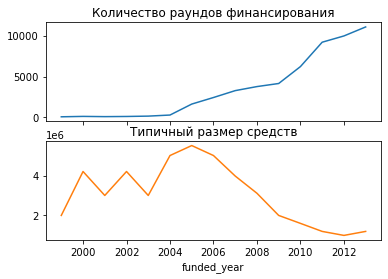

In [51]:
# Строим линейный график
filtered_pivot.plot(kind='line',
            subplots=True,
            sharex=True,
            sharey=False,
            legend=False,
            title=['Количество раундов финансирования', 'Типичный размер средств'])

# Подписываем оси
plt.xlabel('funded_year')
plt.show()

Типичный размер собранных в рамках одного раунда средств был максимален в 2005 году, далее наблюдается динамика снижения до 2012 года. 

В 2013 году наблюдалась положительная динамика по количеству раундов финансирования - устойчивый положительный тренд берет начало в 2002 году. Раазмер выделяемых средств в 2013 году увеличился по сравнению с 2012 годом, несмотря на отрицательный тренд в 2005-2012 гг.



### 2.2. Люди и их образование

Заказчик хочет понять, зависит ли полнота сведений о сотрудниках (например, об их образовании) от размера компаний. Необходимо оценить, насколько информация об образовании сотрудников полна. Необходимо разделите все компании на несколько групп по количеству сотрудников и оценить среднюю долю сотрудников без информации об образовании в каждой из групп.

In [52]:
# Объединяем данные датасетов df_education и df_people
df_people_education = df_education.merge(df_people, how='outer', left_on='person_id', right_on='id')

In [53]:
df_people_education

,id_x,person_id,instituition,graduated_at,id_y,first_name,last_name,company_id,network_username
0,1.0,6117.0,NaN,NaT,6117.0,Maurice,Rompre,2430.0,NaN
1,2.0,6136.0,"Washington University, St. Louis",1990-01-01,6136.0,John,Green,2454.0,NaN
2,3.0,6136.0,Boston University,1992-01-01,6136.0,John,Green,2454.0,NaN
3,4.0,6005.0,University of Greenwich,2006-01-01,6005.0,Sridhar,Gundaiah,2360.0,NaN
4,5.0,5832.0,Rice University,NaT,5832.0,David,Peters,2033.0,NaN
...,...,...,...,...,...,...,...,...,...
268243,NaN,NaN,NaN,NaT,99996.0,Rick,Tamberrino,NaN,tamberrino
268244,NaN,NaN,NaN,NaT,99998.0,Adam,Neumann,NaN,NaN
268245,NaN,NaN,NaN,NaT,99999.0,Ramon,Peypoch,NaN,NaN
268246,NaN,NaN,NaN,NaT,175827.0,mahesh,kumar,NaN,socialnethubs


In [54]:
# Переименуем столбец с данными идентификатора записи об образовании
df_people_education = df_people_education.rename(columns={'id_x': 'id_education'})

In [55]:
# На основе объединенного датасета, рассчитаем количество сотрудников в каждой компании
df_grouped = df_people_education.groupby('company_id')['person_id'].count()

In [56]:
# Серию полученных значений преобразуем в датафрейм
df_grouped = df_grouped.reset_index()

In [57]:
# Новый датафрейм df_grouped с данными о количестве сотрудников
df_grouped

,company_id,person_id
0,1.0,2
1,2.0,1
2,3.0,4
3,4.0,17
4,5.0,68
...,...,...
22917,285897.0,2
22918,285953.0,0
22919,285972.0,1
22920,285996.0,1


In [58]:
# Присоединим df_grouped к df_people_education
df_merged = df_grouped.merge(df_people_education, how='outer', on='company_id')

In [59]:
# Объединенные датафреймы
df_merged

,company_id,person_id_x,id_education,person_id_y,instituition,graduated_at,id_y,first_name,last_name,network_username
0,1.0,2.0,706.0,3.0,Washington University in St Louis,NaT,3.0,Kevin,Flaherty,NaN
1,1.0,2.0,707.0,3.0,Indiana University,NaT,3.0,Kevin,Flaherty,NaN
2,1.0,2.0,NaN,NaN,NaN,NaT,104800.0,Alex,Weinstein,alexweinstein
3,2.0,1.0,594.0,9729.0,Tamilnadu College of engineering,1998-01-01,9729.0,Bharath,Balasubramanian,spinfree
4,3.0,4.0,43581.0,6456.0,"Indian Institute of Technology, Madras",1989-01-01,6456.0,Sridhar,Vembu,NaN
...,...,...,...,...,...,...,...,...,...,...
268243,NaN,NaN,NaN,NaN,NaN,NaT,99996.0,Rick,Tamberrino,tamberrino
268244,NaN,NaN,NaN,NaN,NaN,NaT,99998.0,Adam,Neumann,NaN
268245,NaN,NaN,NaN,NaN,NaN,NaT,99999.0,Ramon,Peypoch,NaN
268246,NaN,NaN,NaN,NaN,NaN,NaT,175827.0,mahesh,kumar,socialnethubs


In [60]:
# Переименуем столбец с данными о количестве сотрудников
df_merged = df_merged.rename(columns={'person_id_x': 'Количество_сотрудников'})

In [61]:
# Отфильтруем строки с значениями равными нулю в столбце Количество_сотрудников 
# (исходим из предположения, что количество сотрудников не может быть равно нулю и эти данные могут исказить результаты анализа)
df_merged = df_merged.loc[df_merged['Количество_сотрудников'] >0]

In [62]:
# Посмотрим на описание данных в столбце Количество_сотрудников
df_merged['Количество_сотрудников'].describe()

count    33430.000000
mean        10.864254
std         37.416623
min          1.000000
25%          2.000000
50%          2.000000
75%          5.000000
max        300.000000
Name: Количество_сотрудников, dtype: float64

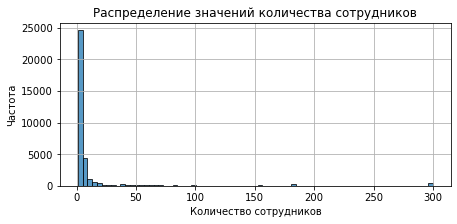

In [63]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим гистограмму с помощью pandas через plot(kind='hist')
df_merged['Количество_сотрудников'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=75, # Устанавливаем количество корзин - всего 25
                alpha=0.75,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

# Настраиваем оформление графика
plt.title('Распределение значений количества сотрудников')
plt.xlabel('Количество сотрудников')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

 Видим, что минимальное количество сотрудников в компании - 1, максимальное - 300 человек, разброс большой. Среднее количество сотрудников 10, медианное значение 2, стандартное отклонение 37 подтверждают нерасномерность распределения данных.  
 
 Разделим  все компании на 4 групп по количеству сотрудников, как это принято в экономике: 
- микропредприятие (от 1 до 15 человек включительно), 
- малые компании (от 16 до 100 человек включительно), 
- средние компании (от 101 до 250 человек включительно),
- крупные компании (свыше 250 человек).

In [64]:
# Функция для категоризации значений
def categorize(count):
    if 1 <= count <= 15:
        return 'микропредприятие'
    elif 16 <= count <= 100:
        return 'малая компания'
    elif 101 <= count <= 250:
        return 'средняя компания'
    else:
        return 'крупная компания'

# Применение функции к данным и сохранение нового столбца
df_merged['Категория_компании'] = df_merged['Количество_сотрудников'].apply(categorize)

In [65]:
#  Проверим обновленный датафрейм 
df_merged.head(20)

,company_id,Количество_сотрудников,id_education,person_id_y,instituition,graduated_at,id_y,first_name,last_name,network_username,Категория_компании
0,1.0,2.0,706.0,3.0,Washington University in St Louis,NaT,3.0,Kevin,Flaherty,NaN,микропредприятие
1,1.0,2.0,707.0,3.0,Indiana University,NaT,3.0,Kevin,Flaherty,NaN,микропредприятие
2,1.0,2.0,NaN,NaN,NaN,NaT,104800.0,Alex,Weinstein,alexweinstein,микропредприятие
3,2.0,1.0,594.0,9729.0,Tamilnadu College of engineering,1998-01-01,9729.0,Bharath,Balasubramanian,spinfree,микропредприятие
4,3.0,4.0,43581.0,6456.0,"Indian Institute of Technology, Madras",1989-01-01,6456.0,Sridhar,Vembu,NaN,микропредприятие
5,3.0,4.0,43582.0,6456.0,Princeton University,NaT,6456.0,Sridhar,Vembu,NaN,микропредприятие
6,3.0,4.0,47870.0,5.0,The Aji Network,2005-01-01,5.0,Ian,Wenig,NaN,микропредприятие
7,3.0,4.0,47871.0,5.0,McGill University,1986-01-01,5.0,Ian,Wenig,NaN,микропредприятие
8,3.0,4.0,NaN,NaN,NaN,NaT,4.0,Raju,Vegesna,NaN,микропредприятие
9,4.0,17.0,905.0,11998.0,Eastern Michigan University,2003-01-01,11998.0,Joe,Stump,NaN,малая компания


Создадим новый столбец с информацией о наличии записи об образовании сотрудника.

In [66]:
# Функция 
def categorize(x):
    if x>0:
        return 0
    else:
        return 1

# Применение функции к данным и сохранение нового столбца
df_merged['Нет_образования'] = df_merged['id_education'].apply(categorize)

In [67]:
# Найдем долю сотрудников без образования в каждой категории
df_merged.groupby('Категория_компании')['Нет_образования'].mean().sort_values()

Категория_компании
малая компания      0.141963
микропредприятие    0.142133
средняя компания    0.186441
крупная компания    0.202128
Name: Нет_образования, dtype: float64

В малых и микропредприятиях доля сотрудников без информации об образовании составляет по 14%, в средних компаниях - 19%, в крупных - 20%. С ростом компании растет и доля сотрудников без информации об образовании.

Таблицу degrees.csv теоретически можно присоединить к данным по полю object_id с данными идентификатора сотрудника, но это требует коррекции данных и преобразования типа object  в числовой. Для достижения целей анализа достаточно тех данных, которые мы проанализировали выше. 

### 2.3. Объединять или не объединять — вот в чём вопрос

Некоторые названия столбцов встречаются в датасетах чаще других. В результате предварительной проверки датасетов было выяснено, что столбец `company_id` подходит для объединения данных.

- Установим, подходит ли для объединения данных столбец `network_username`, который встречается в нескольких датасетах. Нам необходимо понимать, дублируется ли для разных датасетов информация в столбцах с таким названием, и если да — то насколько часто.
- Оценим, можно ли использовать столбцы с именем `network_username` для объединения данных.

Данные network_username содержатся в двух датафреймах: df_company_and_rounds и df_people. Если данные в рассматриваемых столбцах пересекаются, то столбец можно использовать для объединения датафреймов. Проверим это предположение.

In [68]:
# Создадим множество уникальных значений из df_company_and_rounds
df_company_and_rounds_unique = set(df_company_and_rounds['network_username'])

In [69]:
# Количество уникальных значений в df_company_and_rounds
len(df_company_and_rounds_unique)

79572

In [70]:
# Создадим множество уникальных значений из df_people
df_people_unique = set(df_people['network_username'])

In [71]:
# Количество уникальных значений в df_people
len(df_people_unique)

38422

In [72]:
# Проверим пересечение данных
intersection = df_company_and_rounds_unique.intersection(df_people_unique)

In [73]:
# Рассчитаем количество данных, которые пересекаются
intersection_count = len(intersection)

In [74]:
# Количество одинаковых никнеймов
intersection_count 

2200

Видим, что количество уникальных значений в столбце `network_username` датафрейма `df_company_and_rounds` - 79572, в `df_people` количество уникальных значений в аналогичном столбце - 38422, в то время как количество пересекающихся значений существенно меньше - 2200, что позволяет сделать вывод о том, что данный столбец некорректно использовать для объединения данных. 


### 2.4. Проблемный датасет и причина возникновения пропусков

Во время собственного анализа данных у заказчика больше всего вопросов возникло к датасету `company_and_rounds.csv`. В нём много пропусков как раз в информации о раундах, которая заказчику важна.

Приведем данные в вид, который позволит в дальнейшем проводить анализ в разрезе отдельных компаний. 

In [75]:
# Уникальные значения в столбце company_id
a = df_company_and_rounds['company_id'].unique()

In [76]:
# Количество уникальных значений в столбце company_id
df_company_and_rounds['company_id'].nunique()

31939

In [77]:
# Уникальные значения в столбце company_ID
b = df_company_and_rounds['company_ID'].unique()

In [78]:
# Количество уникальных значений в столбце company_ID
df_company_and_rounds['company_ID'].nunique()

196553

In [79]:
# Находим пересечение уникальных значений по столбцам company_id
len(np.intersect1d(a, b))

31707

Можем сделать вывод, что значения в столбцах с company_id и company_ID пересекаются, значения последнего столбца company_ID возьмем за основу.

Создадим новый столбец - выберем существующие значения в столбцах company_id и company_ID с помощью функции и запишем их в новый столбец id.

In [80]:
# Функция 
def function(x, y):
    if x>0:
        return x
    elif y:
        return y
    else:
        return 'нет данных'

# Применение функции к данным и сохранение нового столбца
df_company_and_rounds['company_id_found'] = df_company_and_rounds.apply(lambda row: function(row['company_ID'], row['company_id']), axis=1)

In [81]:
# Проверим датафрейм с новым столбцом
df_company_and_rounds

,company_ID,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,...,company_id,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round,funded_year,company_id_found
0,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,1.0,2005-10-01,series-a,5250000.0,0.0,2.0,0.0,1.0,2005.0,1.0
1,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,1.0,2007-01-01,series-b,9500000.0,0.0,3.0,0.0,0.0,2007.0,1.0
2,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,1.0,2008-05-19,series-c+,25000000.0,0.0,4.0,1.0,0.0,2008.0,1.0
3,10.0,Flektor,games_video,acquired,NaT,NaT,flektor.com,NaN,USA,0.0,...,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0
4,100.0,There,games_video,acquired,NaT,NaT,there.com,NaN,USA,0.0,...,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217769,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,...,282847.0,2011-01-31,other,5500000.0,0.0,0.0,1.0,1.0,2011.0,282847.0
217770,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,...,55477.0,2011-01-13,venture,10633300.0,0.0,0.0,0.0,1.0,2011.0,55477.0
217771,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,...,55477.0,2012-05-31,venture,2125720.0,0.0,0.0,1.0,0.0,2012.0,55477.0
217772,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,...,283492.0,2013-12-03,venture,3602480.0,0.0,5.0,1.0,1.0,2013.0,283492.0


 Датасет df_company_and_rounds фактически состоит из 2-х таблиц - данных по компаниям, данных по раундам финансирования. Разделим df_company_and_rounds на две таблицы.

In [82]:
#Создаем таблицу по компаниям
df_company = df_company_and_rounds[['company_id_found', 'name', 'category_code', 'status', 
                             'founded_at', 'closed_at', 'domain', 
                             'network_username', 'country_code', 
                             'investment_rounds', 'funding_rounds', 
                            'funding_total', 'milestones']]

In [83]:
#Убираем дубли записей
df_company=df_company.drop_duplicates(subset=['company_id_found', 'name', 'category_code', 'status', 
                             'founded_at', 'closed_at', 'domain', 
                             'network_username', 'country_code', 'investment_rounds', 'funding_rounds', 
                            'funding_total', 'milestones'], keep='first')

In [84]:
#Удаляем пропуски по колонке (ранее было выявлено, что в колонке минимальное количество пропусков)
df_company=df_company.dropna(subset=['name'])

In [85]:
df_company

,company_id_found,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,funding_rounds,funding_total,milestones
0,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,3.0,39750000.0,5.0
3,10.0,Flektor,games_video,acquired,NaT,NaT,flektor.com,NaN,USA,0.0,0.0,0.0,0.0
4,100.0,There,games_video,acquired,NaT,NaT,there.com,NaN,USA,0.0,0.0,0.0,4.0
5,10000.0,MYWEBBO,network_hosting,operating,2008-07-26,NaT,mywebbo.com,NaN,NaN,0.0,0.0,0.0,0.0
6,10001.0,THE Movie Streamer,games_video,operating,2008-07-26,NaT,themoviestreamer.com,NaN,NaN,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
217462,183352.0,Mattress Source,NaN,operating,NaT,NaT,mattresssourcestl.com,network,NaN,0.0,0.0,0.0,0.0
217463,3429.0,Zend Technologies,software,operating,1999-01-01,NaT,zend.com,networkzend,USA,0.0,4.0,44000000.0,6.0
217467,7748.0,Flowgram,web,closed,2007-06-01,2008-06-11,flowgram.com,network,USA,0.0,1.0,1300000.0,3.0
217468,174536.0,Pphotonet,games_video,operating,2012-05-01,NaT,pPhotonet.co,pPhotonet,NaN,0.0,0.0,0.0,0.0


In [86]:
#Создаем таблицу по раундам инвестирования
df_rounds = df_company_and_rounds[['company_id_found', 'raised_amount', 'funding_round_id', 
                            'funded_at', 'funding_round_type', 'pre_money_valuation', 
                            'participants', 'is_first_round', 
                            'is_last_round', 'funded_year']]

In [87]:
#Убираем дубли записей
df_rounds=df_rounds.drop_duplicates(subset=['company_id_found', 'raised_amount', 'funding_round_id', 
                            'funded_at', 'funding_round_type', 'pre_money_valuation', 
                            'participants', 'is_first_round', 
                            'is_last_round', 'funded_year'], keep='first')

In [88]:
#Находим пропуски
display(df_rounds[df_rounds['funding_round_type'].isna()].head()) 

,company_id_found,raised_amount,funding_round_id,funded_at,funding_round_type,pre_money_valuation,participants,is_first_round,is_last_round,funded_year
3,10.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
4,100.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
5,10000.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
6,10001.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
7,10002.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN


In [89]:
#Удаляем пропуски по колонке
df_rounds=df_rounds.dropna(subset=['funding_round_type'])

In [90]:
df_rounds

,company_id_found,raised_amount,funding_round_id,funded_at,funding_round_type,pre_money_valuation,participants,is_first_round,is_last_round,funded_year
0,1.0,5250000.0,888.0,2005-10-01,series-a,0.0,2.0,0.0,1.0,2005.0
1,1.0,9500000.0,889.0,2007-01-01,series-b,0.0,3.0,0.0,0.0,2007.0
2,1.0,25000000.0,2312.0,2008-05-19,series-c+,0.0,4.0,1.0,0.0,2008.0
15,1001.0,5000000.0,1644.0,2008-02-26,series-a,0.0,3.0,1.0,1.0,2008.0
20,10014.0,0.0,6682.0,2008-09-01,angel,0.0,1.0,1.0,1.0,2008.0
...,...,...,...,...,...,...,...,...,...,...
217769,282847.0,5500000.0,56454.0,2011-01-31,other,0.0,0.0,1.0,1.0,2011.0
217770,55477.0,10633300.0,56542.0,2011-01-13,venture,0.0,0.0,0.0,1.0,2011.0
217771,55477.0,2125720.0,56543.0,2012-05-31,venture,0.0,0.0,1.0,0.0,2012.0
217772,283492.0,3602480.0,56928.0,2013-12-03,venture,0.0,5.0,1.0,1.0,2013.0



## Шаг 3. Исследовательский анализ объединённых таблиц



### 3.1. Объединение данных

Заказчика прежде всего интересуют те компании, которые меняли или готовы менять владельцев. Получение инвестиций или финансирования, по мнению заказчика, означает интерес к покупке или продаже компании.

In [91]:
# Создаем датафрейм с компаниями, которые меняли или готовы менять владельцев
df_company_ready_change = df_company.loc[(df_company['funding_rounds'] > 0) | (df_company['investment_rounds'] > 0) | (df_company['status'] == 'acquired')]

In [92]:
df_company_ready_change

,company_id_found,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,funding_rounds,funding_total,milestones
0,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,3.0,39750000.0,5.0
3,10.0,Flektor,games_video,acquired,NaT,NaT,flektor.com,NaN,USA,0.0,0.0,0.0,0.0
4,100.0,There,games_video,acquired,NaT,NaT,there.com,NaN,USA,0.0,0.0,0.0,4.0
15,1001.0,FriendFeed,web,acquired,2007-10-01,NaT,friendfeed.com,friendfeed,USA,0.0,1.0,5000000.0,3.0
20,10014.0,Mobclix,mobile,acquired,2008-03-01,NaT,mobclix.com,mobclix,USA,0.0,1.0,0.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
217458,1344.0,Vobile,web,operating,2005-01-01,NaT,vobileinc.com,networkmobile,USA,0.0,1.0,10000000.0,0.0
217459,142181.0,Stop Being Watched,software,operating,2010-06-10,NaT,stopbeingwatched.com,SBWinfonetwork,USA,0.0,1.0,500000.0,1.0
217463,3429.0,Zend Technologies,software,operating,1999-01-01,NaT,zend.com,networkzend,USA,0.0,4.0,44000000.0,6.0
217467,7748.0,Flowgram,web,closed,2007-06-01,2008-06-11,flowgram.com,network,USA,0.0,1.0,1300000.0,3.0



### 3.2. Анализ выбросов

Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

Необходимо оценить, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся.

In [93]:
# Отфильтруем значения больше нуля 
df_filtered = df_company_ready_change.loc[df_company_ready_change['funding_total'] > 0]

In [94]:
df_filtered

,company_id_found,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,funding_rounds,funding_total,milestones
0,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,3.0,39750000.0,5.0
15,1001.0,FriendFeed,web,acquired,2007-10-01,NaT,friendfeed.com,friendfeed,USA,0.0,1.0,5000000.0,3.0
21,10015.0,Fitbit,health,operating,2007-10-01,NaT,fitbit.com,fitbit,USA,0.0,5.0,68069200.0,0.0
26,100155.0,MTPV,cleantech,operating,2003-01-01,NaT,mtpv.com,NaN,USA,0.0,3.0,10125300.0,1.0
32,10018.0,Demandbase,analytics,operating,2006-01-01,NaT,demandbase.com,Demandbase,USA,0.0,3.0,33000000.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
217458,1344.0,Vobile,web,operating,2005-01-01,NaT,vobileinc.com,networkmobile,USA,0.0,1.0,10000000.0,0.0
217459,142181.0,Stop Being Watched,software,operating,2010-06-10,NaT,stopbeingwatched.com,SBWinfonetwork,USA,0.0,1.0,500000.0,1.0
217463,3429.0,Zend Technologies,software,operating,1999-01-01,NaT,zend.com,networkzend,USA,0.0,4.0,44000000.0,6.0
217467,7748.0,Flowgram,web,closed,2007-06-01,2008-06-11,flowgram.com,network,USA,0.0,1.0,1300000.0,3.0


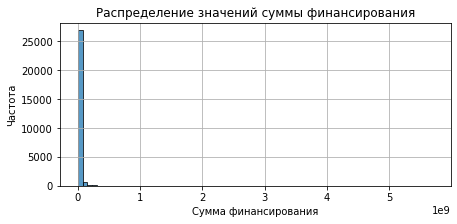

In [95]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим гистограмму с помощью pandas через plot(kind='hist')
df_filtered['funding_total'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=75, # Устанавливаем количество корзин - всего 25
                alpha=0.75,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

# Настраиваем оформление графика
plt.title('Распределение значений суммы финансирования')
plt.xlabel('Сумма финансирования')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

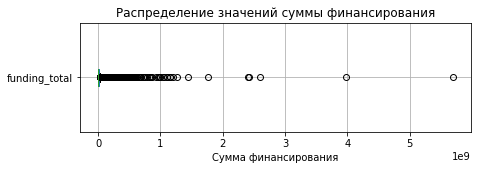

In [96]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце balance
df_filtered.boxplot(column='funding_total', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение значений суммы финансирования')
plt.xlabel('Сумма финансирования')

# Выводим график
plt.show()

In [97]:
# Изучим статистические показатели столбца funding_total 
df_filtered['funding_total'].describe()

count    2.787400e+04
mean     1.481652e+07
std      6.775936e+07
min      2.910000e+02
25%      5.000000e+05
50%      2.564500e+06
75%      1.100000e+07
max      5.700000e+09
Name: funding_total, dtype: float64

Если опираться на графики, можно отметить разброс шкалы от 0 до 5,7 млрд., выбивающимися знаяениями являются значения значения финансирования более 1,5 млрд.

 В соответствии с данными стат.анализа, значение медианы 2,6 млн. отличается от среднего занчения равного 14,8 млн., стандартное отклонение 67,8 млн., минимальное значение 291, максимальное 5,7 млрд. Данные говорят о неравномерности распределения значений и разбросе данных. 
 
 Обычным способом найти типичные значения не получилось, можно лишь указать, что они находятся в диапазоне от значения чуть больше 0 до примерно 1,5 млрд. 

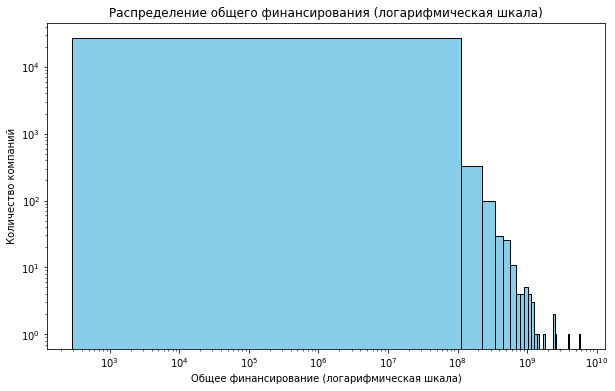

In [98]:
plt.figure(figsize=(10, 6))
plt.hist(df_filtered['funding_total'], bins=50, color='skyblue', edgecolor='black', log=True)
plt.xscale('log')  # Логарифмическая шкала по оси X
plt.xlabel('Общее финансирование (логарифмическая шкала)')
plt.ylabel('Количество компаний')
plt.title('Распределение общего финансирования (логарифмическая шкала)')
plt.show()


### 3.3. Куплены забесплатно?

- Исследуйте компании, которые были проданы за ноль или за один доллар, и при этом известно, что у них был ненулевой общий объём финансирования.

- Рассчитайте аналитически верхнюю и нижнюю границу выбросов для столбца `funding_total` и укажите, каким процентилям границы соответствуют.

In [99]:
# Присоединяем датафрейм с данными о проданных компаниях
df_merged = df_filtered.merge(df_acquisition, how='left', left_on='company_id_found', right_on='acquired_company_id')

In [100]:
# Фильтруем объединенный датафрейм 
df_merged_filtered = df_merged.loc[(df_merged['price_amount'] == 0) | (df_merged['price_amount'] == 1) ]

In [101]:
df_merged_filtered 

,company_id_found,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,funding_rounds,funding_total,milestones,id,acquiring_company_id,acquired_company_id,term_code,price_amount,acquired_at
13,10054.0,Jumptap,mobile,acquired,2005-01-01,NaT,jumptap.com,jumptap,USA,0.0,7.0,121500000.0,3.0,9288.0,23283.0,10054.0,cash_and_stock,0.0,2013-08-13
35,101312.0,SideTour,web,acquired,2011-06-01,NaT,sidetour.com,sidetour,USA,0.0,3.0,4000000.0,2.0,9653.0,11391.0,101312.0,NaN,0.0,2013-09-18
38,101340.0,ChoicePass,enterprise,acquired,2011-07-01,NaT,choicepass.com,choicepass,USA,0.0,1.0,250000.0,1.0,7272.0,1972.0,101340.0,NaN,0.0,2012-06-18
39,10137.0,Producteev,software,acquired,2008-07-08,NaT,producteev.com,producteev,USA,0.0,3.0,1310000.0,2.0,8254.0,757.0,10137.0,cash_and_stock,0.0,2012-11-05
40,10139.0,TradeCard,enterprise,acquired,1999-01-01,NaT,tradecard.com,TradeCard,USA,0.0,2.0,44925000.0,1.0,9326.0,44008.0,10139.0,NaN,0.0,2013-04-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27876,99.0,Amie Street,web,acquired,2011-07-04,NaT,amiestreet.com,amiestreet_logs,USA,0.0,2.0,3900000.0,0.0,7024.0,317.0,99.0,NaN,0.0,2010-09-22
27878,9905.0,UBmatrix,software,acquired,2005-01-01,NaT,ubmatrix.com,NaN,USA,0.0,2.0,5172350.0,0.0,3381.0,41119.0,9905.0,NaN,0.0,2010-06-24
27880,992.0,wunderloop,advertising,acquired,1999-01-01,NaT,wunderloop.com,NaN,USA,0.0,1.0,10000000.0,1.0,9916.0,19182.0,992.0,NaN,0.0,2010-07-02
27892,997.0,Zimbra,enterprise,acquired,2003-01-01,NaT,zimbra.com,zimbra,USA,0.0,1.0,14500000.0,3.0,9121.0,415.0,997.0,NaN,0.0,2013-07-15


Рассчитаем границы выбросов для столбца funding_total.

In [102]:
df_merged_filtered['funding_total'].describe(percentiles=[0.25, 0.5, 0.9, 0.91, 0.92, 0.93, 0.95, 0.99])

count    1.618000e+03
mean     1.815296e+07
std      1.445030e+08
min      3.750000e+03
25%      2.000000e+06
50%      6.000000e+06
90%      3.301581e+07
91%      3.589400e+07
92%      3.900780e+07
93%      4.200000e+07
95%      5.148750e+07
99%      1.515529e+08
max      5.700000e+09
Name: funding_total, dtype: float64

Характер значений в столбце funding_total  объединенного и отфильтрованного датаырейма не поменялся, данные также распределены асимметрично. 

Для обнаружения выбросов данных рассчитаем межквартильный диапазон.

In [103]:
# Вычисляем квартили Q1 и Q3
Q1 = df_merged_filtered['funding_total'].quantile(0.25)
Q3 = df_merged_filtered['funding_total'].quantile(0.75)

In [104]:
# Вычисляем межквартильный размах IQR
IQR = Q3 - Q1

In [105]:
# Определяем верхний порог для выбросов
upper_bound = Q3 + 1.5 * IQR

In [106]:
# Определяем нижний порог для выбросов
lower_bound = Q1 - 1.5 * IQR

In [107]:
display(upper_bound)
display(lower_bound)

35750000.0

-18250000.0

Все что попадает в интервал от нижнего до верхнего пределов — это «нормальные», типичные значения наших данных. Значения, которые находятся за пределами этого интервала, являются выбросами. Если нижний предел - отрицательная величина, следовательно, все значения наших данных слева являются типичными.

Учитывая асимметричность распределения данных, можем определить нижнюю границу соответствующей 0 процентилю, верхняя граница примерно равна 91-му процентилю.


### 3.4. Цены стартапов по категориям

Среди категорий стартапов выделите категории стартапов, характеризующиеся:

- типично высокими ценами;
- и наибольшим разбросом цен за стартап.

Данные о покупке стартапов представлены в объединенном датафреме df_merged. Отфильтруем датафрейм - оставим данные стартапов стоимостью более 1 доллара.

In [108]:
# Фильтруем датафрейм 
df_merged_filtered_price = df_merged.loc[df_merged['price_amount'] > 1]

In [109]:
# Рассчитываем значение медианы для стартапов каждой категории (типичное значение)
df_merged_filtered_price.groupby('category_code')['price_amount'].median().sort_values(ascending=False).head(15)

category_code
transportation    1.100000e+09
fashion           2.700000e+08
biotech           2.500000e+08
analytics         2.000000e+08
medical           1.650000e+08
cleantech         1.580000e+08
finance           1.415000e+08
security          1.400000e+08
enterprise        1.305000e+08
health            1.300000e+08
semiconductor     1.240000e+08
consulting        1.225000e+08
ecommerce         1.100000e+08
search            1.075000e+08
messaging         1.010000e+08
Name: price_amount, dtype: float64

In [110]:
# Рассчитываем значение стандартного отклонения для стартапов каждой категории 
df_merged_filtered_price.groupby('category_code')['price_amount'].std().sort_values(ascending=False)

category_code
semiconductor       1.234068e+09
software            8.582854e+08
public_relations    6.086066e+08
network_hosting     5.769147e+08
finance             5.729880e+08
photo_video         4.311422e+08
biotech             3.538007e+08
games_video         3.527361e+08
enterprise          3.428923e+08
advertising         3.328762e+08
hardware            3.152494e+08
web                 3.062750e+08
mobile              2.416406e+08
cleantech           2.304867e+08
security            1.984707e+08
ecommerce           1.875959e+08
medical             1.659058e+08
music               1.599781e+08
search              1.507719e+08
other               1.377810e+08
consulting          1.099405e+08
news                1.069057e+08
manufacturing       9.616652e+07
analytics           9.296774e+07
travel              8.131728e+07
messaging           6.308988e+07
social              6.295286e+07
real_estate         2.616295e+07
health              2.516611e+07
automotive                   

Типично высокими ценами (стоимость более 100 млн.) характеризуются стартапы следующих категорий:
- transportation    (1 млрд.);
- fashion          (270 млн.);
- biotech           (250 млн.);
- analytics         (200 млн.);
- medical           (165 млн.);
- cleantech         (158 млн.);
- finance           (142 млн.);
- security          (140 млн.);
- enterprise        (131 млн.);
- health            (130 млн.);
- semiconductor     (124 млн.);
- consulting        (123 млн.);
- ecommerce         (110 млн.);
- search            (108 млн.);
- messaging         (101 млн.).

Наибольший разброс цен на стратапы в следующих 6-ти категориях:
- semiconductor       (1,2 млрд.);
- software            (858 млн.);
- public_relations    (608 млн.);
- network_hosting     (577 млн.);
- finance             (572 млн.);
- photo_video         (431 млн.).

Разброс в остальных категориях отстает от первой шестерки (там более сглажена разность стандартного отклонения предыдущей и последующей категорий).


### 3.5. Сколько раундов продержится стартап перед покупкой

- Необходимо проанализировать столбец `funding_rounds`. Заказчика интересует типичное значение количества раундов для каждого возможного статуса стартапа.
- Построить график, который отображает, сколько в среднем раундов финансирования проходило для стартапов из каждой группы. 

In [111]:
# Найдем медиану (типичное значение) количества раундов для каждого возможного статуса стартапа
df_filtered.groupby('status')['funding_rounds'].median().sort_values()

status
closed       1.0
operating    1.0
acquired     2.0
ipo          2.0
Name: funding_rounds, dtype: float64

In [112]:
# Найдем среднее количества раундов для каждого возможного статуса стартапа
round(df_filtered.groupby('status')['funding_rounds'].mean().sort_values(), 0)

status
closed       1.0
operating    2.0
acquired     2.0
ipo          3.0
Name: funding_rounds, dtype: float64

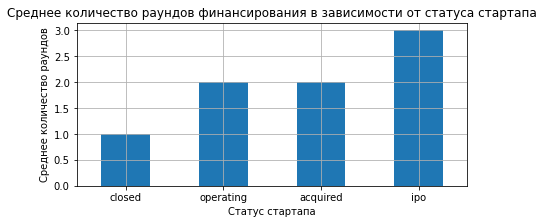

In [113]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
round(df_filtered.groupby('status')['funding_rounds'].mean().sort_values(), 0).plot(
               kind='bar', # Тип графика - столбчатая диаграмма
               rot=0, # Градус вращения подписи по оси Х
               legend=False, # Выключаем легенду
               title=f'Среднее количество раундов финансирования в зависимости от статуса стартапа'
)

# Настраиваем оформление графика
plt.xlabel('Статус стартапа')
plt.ylabel('Среднее количество раундов')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

Количество раундов финансирования связано с конкурентоспособностью стартапа. Закрывшиеся компании имеют самое низкое количество раундов финансирования - 1, работающие компании и проданные компании - в среднем имеют 2 раунда финансирования, компании со статусом IPO - 3 раунда финансирования. 

In [114]:
df_filtered

,company_id_found,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,funding_rounds,funding_total,milestones
0,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,3.0,39750000.0,5.0
15,1001.0,FriendFeed,web,acquired,2007-10-01,NaT,friendfeed.com,friendfeed,USA,0.0,1.0,5000000.0,3.0
21,10015.0,Fitbit,health,operating,2007-10-01,NaT,fitbit.com,fitbit,USA,0.0,5.0,68069200.0,0.0
26,100155.0,MTPV,cleantech,operating,2003-01-01,NaT,mtpv.com,NaN,USA,0.0,3.0,10125300.0,1.0
32,10018.0,Demandbase,analytics,operating,2006-01-01,NaT,demandbase.com,Demandbase,USA,0.0,3.0,33000000.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
217458,1344.0,Vobile,web,operating,2005-01-01,NaT,vobileinc.com,networkmobile,USA,0.0,1.0,10000000.0,0.0
217459,142181.0,Stop Being Watched,software,operating,2010-06-10,NaT,stopbeingwatched.com,SBWinfonetwork,USA,0.0,1.0,500000.0,1.0
217463,3429.0,Zend Technologies,software,operating,1999-01-01,NaT,zend.com,networkzend,USA,0.0,4.0,44000000.0,6.0
217467,7748.0,Flowgram,web,closed,2007-06-01,2008-06-11,flowgram.com,network,USA,0.0,1.0,1300000.0,3.0



## Шаг 4. Итоговый вывод и рекомендации


На первом этапе исследования проведена предобработка данных: 
- загрузка данных и первичное ознакомление;
- скорректированы названия столбцов;
- заменены типы данных;
- изучены пропуски и дубликаты.

Проведено предварительное исследование данных и получены следующие выводы:
- Типичный размер собранных в рамках одного раунда средств был максимален в 2005 году, далее наблюдается динамика снижения до 2012 года.
- В 2013 году наблюдалась положительная динамика по количеству раундов финансирования - устойчивый положительный тренд берет начало в 2002 году. Раазмер выделяемых средств в 2013 году увеличился по сравнению с 2012 годом, несмотря на отрицательный тренд в 2005-2012 гг. (данные по финансированию доступны до 2013 года включительно)
- В малых и микропредприятиях доля сотрудников без информации об образовании составляет по 14%, в средних компаниях - 19%, в крупных - 20%. С ростом компании растет и доля сотрудников без информации об образовании.
- Выявили, что датасет `df_company_and_rounds` фактически состоит из 2-х таблиц - данных по компаниям, данных по раундам финансирования, разделили датасет на 2 таблицы.

Проведен исследовательский анализ данных:
-  Результаты исследования говорят о неравномерности распределения и существенном разбросе данных о размере общего финансирования для одной компании, присутствуют и выбросы данных. Нижняя граница выбросов соответствует 0 процентилю, верхняя граница примерно равна 91-му процентилю.
- Типично высокими ценами (стоимость более 100 млн.) характеризуются стартапы следующих категорий:
 - transportation    (1 млрд.);
 - fashion          (270 млн.);
 - biotech           (250 млн.);
 - analytics         (200 млн.);
 - medical           (165 млн.);
 - cleantech         (158 млн.);
 - finance           (142 млн.);
 - security          (140 млн.);
 - enterprise        (131 млн.);
 - health            (130 млн.);
 - semiconductor     (124 млн.);
 - consulting        (123 млн.);
 - ecommerce         (110 млн.);
 - search            (108 млн.);
 - messaging         (101 млн.).

- Наибольший разброс цен на стратапы в следующих категориях:
 - semiconductor       (1,2 млрд.);
 - software            (858 млн.);
 - public_relations    (608 млн.);
 - network_hosting     (577 млн.);
 - finance             (572 млн.);
 - photo_video         (431 млн.).
- Количество раундов финансирования связано с конкурентоспособностью стартапа. Закрывшиеся компании имеют самое низкое количество раундов финансирования - 1, работающие компании и проданные компании - в среднем имеют 2 раунда финансирования, компании со статусом IPO - 3 раунда финансирования.

Исследование позволяет сделать вывод о том, что рынок стартапов(по состоянию на 2013 год) развивается - в целом растет как объем финансирования, так и количество раундов финансирования. Рынок в значительной степени непредсказуем - данные о финансировании характеризуются широким разбросом. В то же время, стартапы можно проранжировать по степени разброса цен, выделив наиболее дорогие категории, а также категории с широким диапазоном цен, что может в какой-то мере снизить степень неопределенности для инвестора.

Инвестор может принимать решение о покупке стартапа исходя из той степени риска, которую он готов на себя взять. Если высокая степень риска уместена, то можно выбрать стартап из категорий с наибольшим разбросом цен (с ростом риска, растет и потенциальная доходность), если риск нужно минимизировать, то можно выбрать стартап из списка с ценами по категориям, ориентируясь на медианную цену и игнорируя категории с наибольшим разбросом цены.